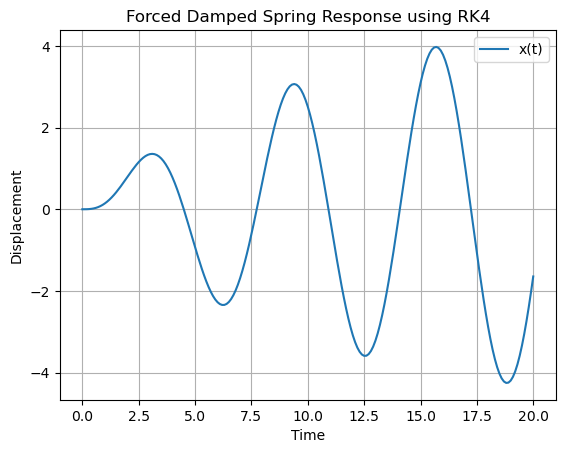

In [6]:
# b
import numpy as np
import matplotlib.pyplot as plt

# Parameters
m = 1.0
c = 0.2
k = 1.0
A = 1.0
omega = 1.0

# Time settings
dt = 0.1
t0 = 0.0
tf = 20.0

# Create time array
t = np.arange(t0, tf + dt, dt)
n = len(t)

# Allocate solution arrays
u = np.zeros(n)   # displacement x(t)
v = np.zeros(n)   # velocity dx/dt

# Initial conditions
u[0] = 0.0
v[0] = 0.0

# RK4 loop
for i in range(n - 1):
  # k1
  k1u = dt * v[i]
  k1v = dt * ((A * np.sin(omega * t[i]) - c * v[i] - k * u[i]) / m)

  # k2
  k2u = dt * (v[i] + 0.5 * k1v)
  k2v = dt * (
    (A * np.sin(omega * (t[i] + 0.5 * dt))
     - c * (v[i] + 0.5 * k1v)
     - k * (u[i] + 0.5 * k1u)) / m
  )

  # k3
  k3u = dt * (v[i] + 0.5 * k2v)
  k3v = dt * (
    (A * np.sin(omega * (t[i] + 0.5 * dt))
     - c * (v[i] + 0.5 * k2v)
     - k * (u[i] + 0.5 * k2u)) / m
  )

  # k4
  k4u = dt * (v[i] + k3v)
  k4v = dt * (
    (A * np.sin(omega * (t[i] + dt))
     - c * (v[i] + k3v)
     - k * (u[i] + k3u)) / m
  )

  # Update state
  u[i + 1] = u[i] + (k1u + 2*k2u + 2*k3u + k4u) / 6
  v[i + 1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) / 6

# Plot displacement
plt.plot(t, u, label='x(t)')
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('Forced Damped Spring Response using RK4')
plt.grid(True)
plt.legend()
plt.show()

c:\Users\Ethan Z\miniconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


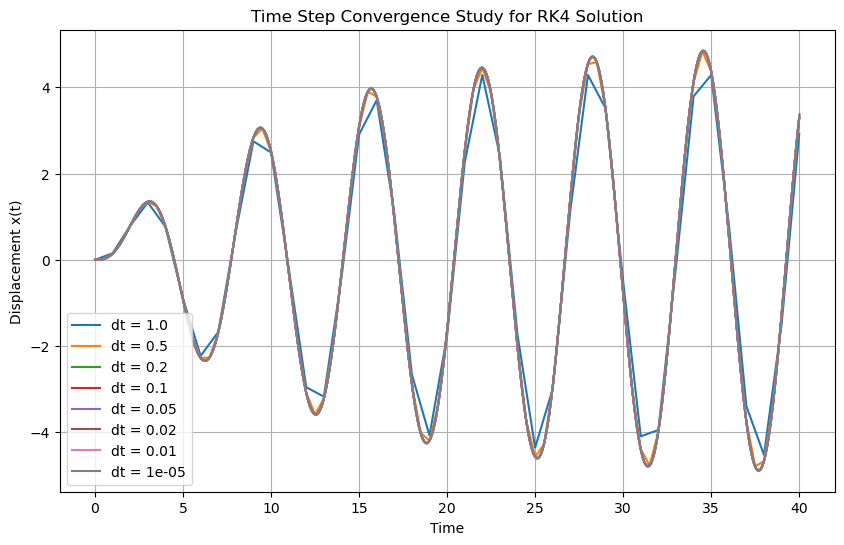

Maximum absolute difference relative to dt = 0.01:
dt =  1.0: max |x_dt - x_ref| = 8.417797e-01
dt =  0.5: max |x_dt - x_ref| = 1.551736e-01
dt =  0.2: max |x_dt - x_ref| = 2.437099e-02
dt =  0.1: max |x_dt - x_ref| = 6.093818e-03
dt = 0.05: max |x_dt - x_ref| = 1.525551e-03
dt = 0.02: max |x_dt - x_ref| = 2.442061e-04
dt = 0.01: max |x_dt - x_ref| = 6.105609e-05


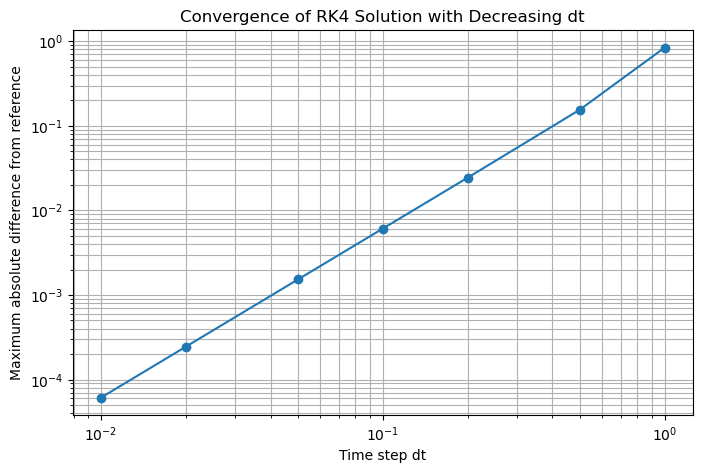


Maximum absolute difference between successive solutions:
dt =  1.0 vs  0.5: max diff = 8.289297e-01
dt =  0.5 vs  0.2: max diff = 1.488073e-01
dt =  0.2 vs  0.1: max diff = 2.437603e-02
dt =  0.1 vs 0.05: max diff = 6.094115e-03
dt = 0.05 vs 0.02: max diff = 7.226316e-02
dt = 0.02 vs 0.01: max diff = 2.442068e-04
dt = 0.01 vs 1e-05: max diff = 6.105609e-05


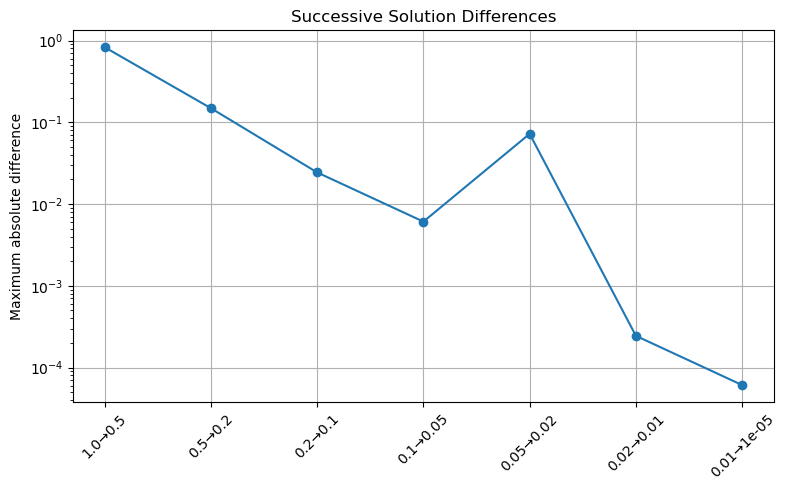

In [7]:
# import math

import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters for the spring system
# -------------------------------
m = 1.0
c = 0.2
k = 1.0
A = 1.0
omega = 1.0

# ----------------------------------------
# RK4 solver for the forced damped oscillator
# ----------------------------------------
def rk4_spring(dt, t0=0.0, tf=40.0, u0=0.0, v0=0.0):
  """
  Solves:
    du/dt = v
    dv/dt = (A*sin(omega*t) - c*v - k*u)/m

  using 4th-order Runge-Kutta with fixed time step dt.
  Returns arrays of t, u, v.
  """
  t = np.arange(t0, tf + dt, dt)
  n = len(t)

  u = np.zeros(n)   # displacement
  v = np.zeros(n)   # velocity

  u[0] = u0
  v[0] = v0

  for i in range(n - 1):
    # k1 values from the current state
    k1u = dt * v[i]
    k1v = dt * ((A * np.sin(omega * t[i]) - c * v[i] - k * u[i]) / m)

    # k2 values from midpoint estimate using k1
    k2u = dt * (v[i] + 0.5 * k1v)
    k2v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k1v)
       - k * (u[i] + 0.5 * k1u)) / m
    )

    # k3 values from midpoint estimate using k2
    k3u = dt * (v[i] + 0.5 * k2v)
    k3v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k2v)
       - k * (u[i] + 0.5 * k2u)) / m
    )

    # k4 values from endpoint estimate using k3
    k4u = dt * (v[i] + k3v)
    k4v = dt * (
      (A * np.sin(omega * (t[i] + dt))
       - c * (v[i] + k3v)
       - k * (u[i] + k3u)) / m
    )

    # Weighted RK4 update
    u[i + 1] = u[i] + (k1u + 2*k2u + 2*k3u + k4u) / 6
    v[i + 1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) / 6

  return t, u, v

# ----------------------------------------
# Candidate time steps for convergence study
# ----------------------------------------
dt_values = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 1e-5]

solutions = {}

for dt in dt_values:
  t, u, v = rk4_spring(dt)
  solutions[dt] = (t, u, v)

# ----------------------------------------
# Plot all x(t) curves on the same figure
# ----------------------------------------
plt.figure(figsize=(10, 6))
for dt in dt_values:
  t, u, _ = solutions[dt]
  plt.plot(t, u, label=f"dt = {dt}")

plt.xlabel("Time")
plt.ylabel("Displacement x(t)")
plt.title("Time Step Convergence Study for RK4 Solution")
plt.grid(True)
plt.legend()
plt.show()

# ----------------------------------------
# Use the finest solution as the reference
# ----------------------------------------
dt_ref = min(dt_values)
t_ref, u_ref, _ = solutions[dt_ref]

# -------------------------------------------------------
# Compare each coarser solution to the reference solution
# using interpolation onto the finest grid
# -------------------------------------------------------
errors_vs_ref = []

for dt in dt_values[:-1]:
  t_coarse, u_coarse, _ = solutions[dt]

  # Interpolate coarse solution onto the reference grid
  u_interp = np.interp(t_ref, t_coarse, u_coarse)

  max_diff = np.max(np.abs(u_interp - u_ref))
  errors_vs_ref.append((dt, max_diff))

# ----------------------------------------
# Print convergence information
# ----------------------------------------
print("Maximum absolute difference relative to dt = 0.01:")
for dt, err in errors_vs_ref:
  print(f"dt = {dt:>4}: max |x_dt - x_ref| = {err:.6e}")

# ----------------------------------------
# Plot error versus dt on a log-log plot
# ----------------------------------------
dt_plot = [item[0] for item in errors_vs_ref]
err_plot = [item[1] for item in errors_vs_ref]

plt.figure(figsize=(8, 5))
plt.loglog(dt_plot, err_plot, marker='o')
plt.xlabel("Time step dt")
plt.ylabel("Maximum absolute difference from reference")
plt.title("Convergence of RK4 Solution with Decreasing dt")
plt.grid(True, which="both")
plt.show()

# ---------------------------------------------------------
# Optional: compare successive dt values instead of only
# comparing everything to the finest reference
# ---------------------------------------------------------
print("\nMaximum absolute difference between successive solutions:")

successive_errors = []

for i in range(len(dt_values) - 1):
  dt_coarse = dt_values[i]
  dt_fine = dt_values[i + 1]

  t_coarse, u_coarse, _ = solutions[dt_coarse]
  t_fine, u_fine, _ = solutions[dt_fine]

  # Interpolate coarse onto finer grid
  u_interp = np.interp(t_fine, t_coarse, u_coarse)

  max_diff = np.max(np.abs(u_interp - u_fine))
  successive_errors.append((dt_coarse, dt_fine, max_diff))

  print(f"dt = {dt_coarse:>4} vs {dt_fine:>4}: max diff = {max_diff:.6e}")

# ----------------------------------------
# Plot successive differences
# ----------------------------------------
plt.figure(figsize=(8, 5))
plt.semilogy(
  range(len(successive_errors)),
  [item[2] for item in successive_errors],
  marker='o'
)
plt.xticks(
  range(len(successive_errors)),
  [f"{item[0]}→{item[1]}" for item in successive_errors],
  rotation=45
)
plt.ylabel("Maximum absolute difference")
plt.title("Successive Solution Differences")
plt.grid(True)
plt.tight_layout()
plt.show()

**c.**
I used 1e-5 as a stopping criterion because it's still reasonably fast to compile. I still choose that as the time step, as it compiled in 26s, which is fine. Stopping criteria/convergence should be based off an estimate of compile time. If you have infinite computing power, use an infinitely small time step, even if the gain is not that much, it's still a gain.

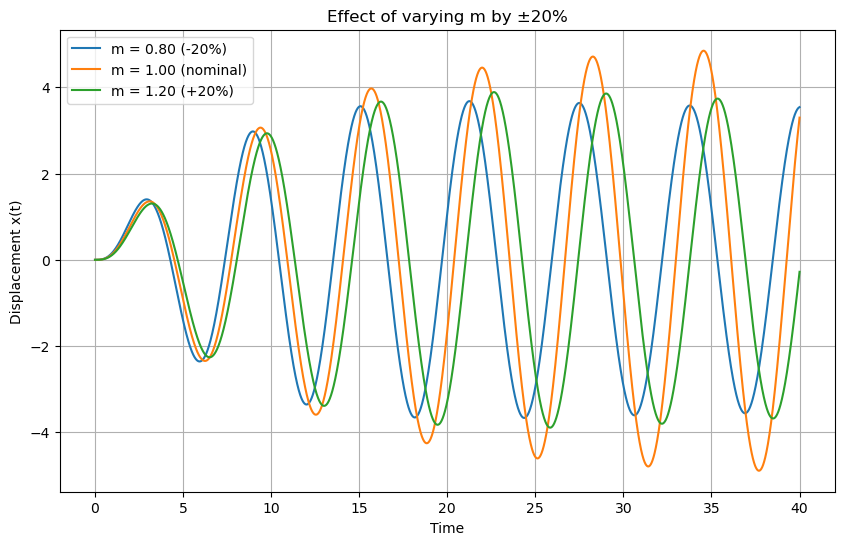

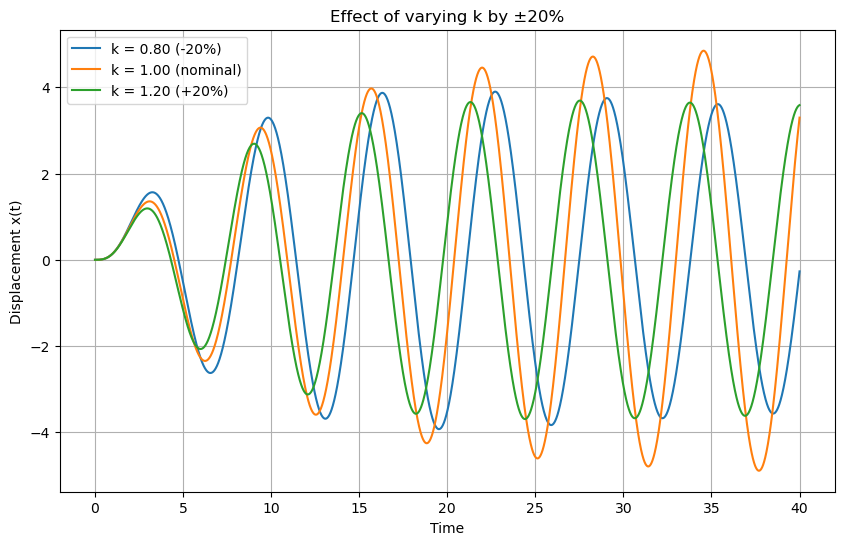

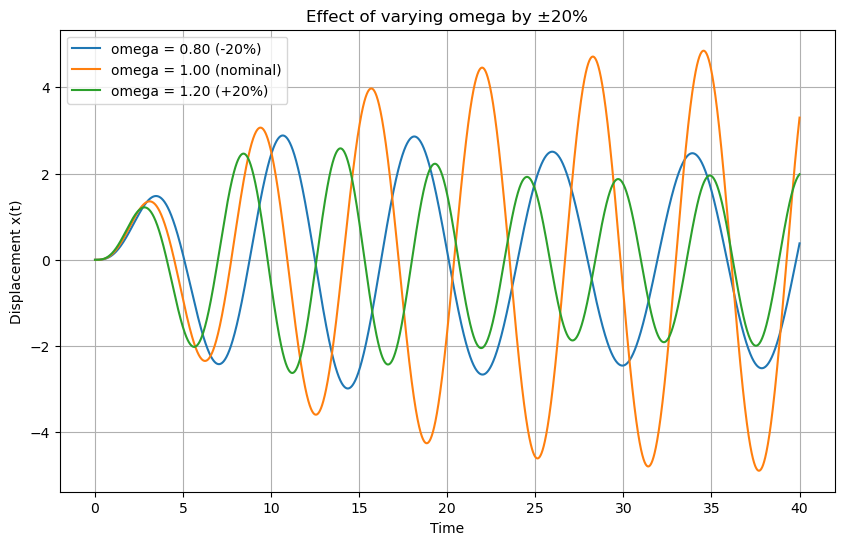

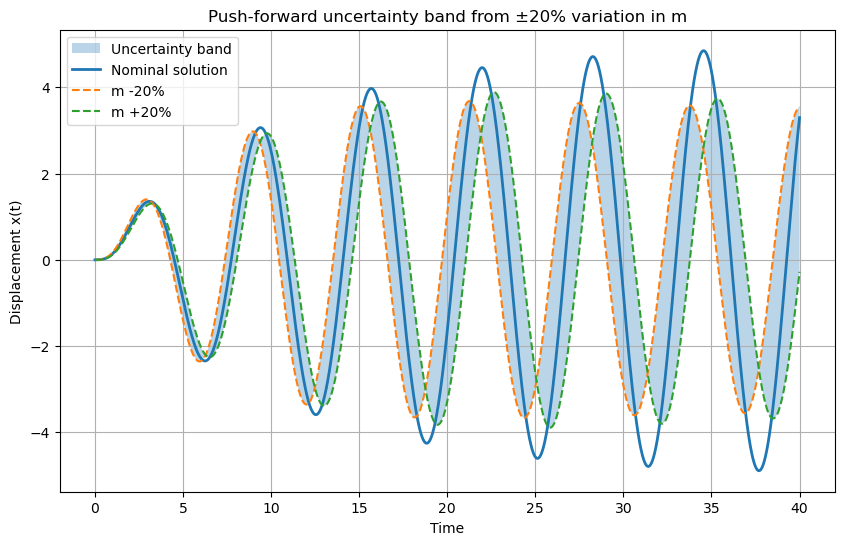

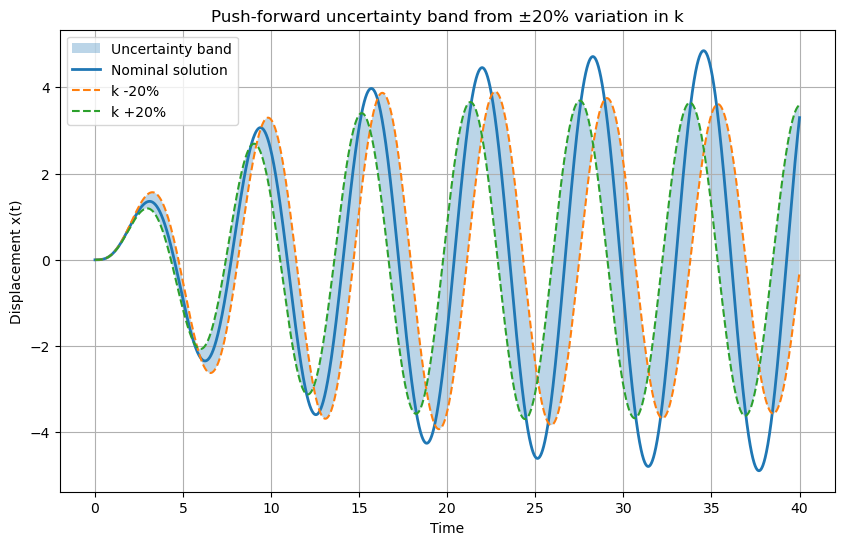

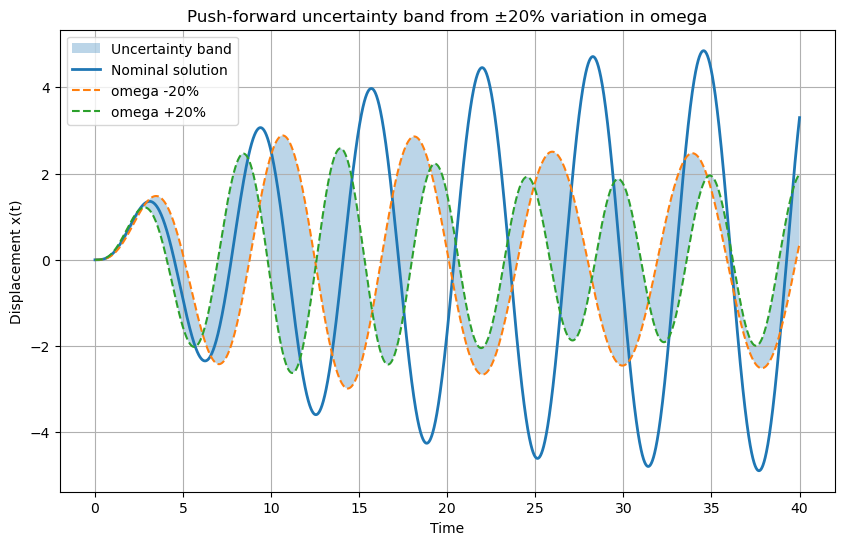

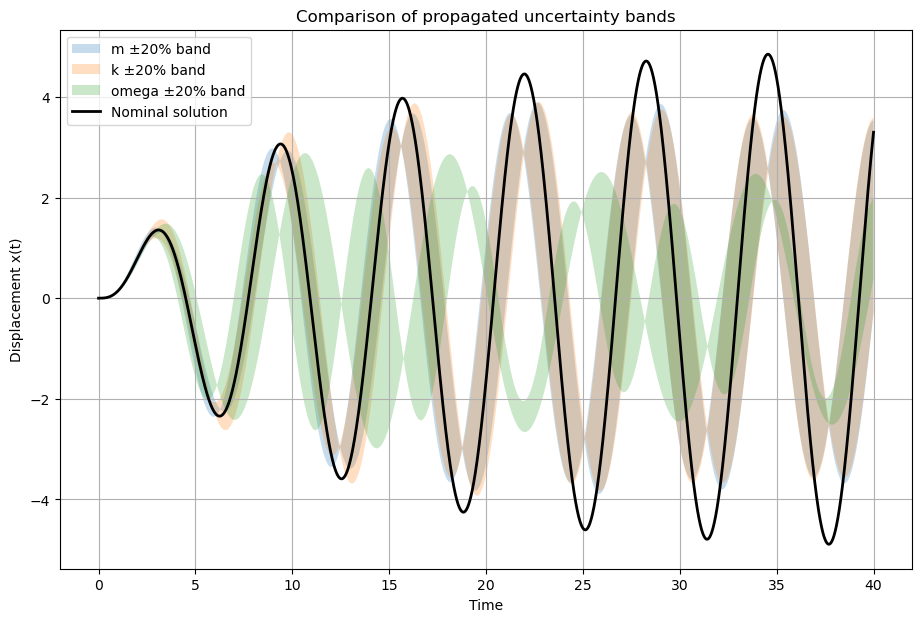

Maximum displacement band width for m ±20%:      5.216582
Maximum displacement band width for k ±20%:      5.218783
Maximum displacement band width for omega ±20%:  5.452943


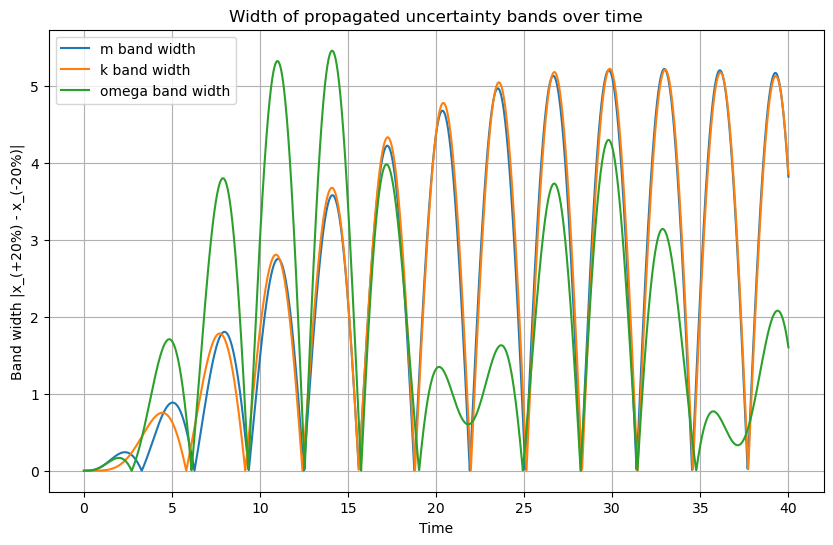

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# RK4 solver for the forced damped oscillator
# ----------------------------------------
def rk4_spring(dt, t0, tf, u0, v0, m, c, k, A, omega):
  """
  Solves:
    du/dt = v
    dv/dt = (A*sin(omega*t) - c*v - k*u) / m

  using 4th-order Runge-Kutta.
  Returns t, u, v arrays.
  """
  t = np.arange(t0, tf + dt, dt)
  n = len(t)

  u = np.zeros(n)   # displacement x(t)
  v = np.zeros(n)   # velocity dx/dt

  u[0] = u0
  v[0] = v0

  for i in range(n - 1):
    # k1
    k1u = dt * v[i]
    k1v = dt * ((A * np.sin(omega * t[i]) - c * v[i] - k * u[i]) / m)

    # k2
    k2u = dt * (v[i] + 0.5 * k1v)
    k2v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k1v)
       - k * (u[i] + 0.5 * k1u)) / m
    )

    # k3
    k3u = dt * (v[i] + 0.5 * k2v)
    k3v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k2v)
       - k * (u[i] + 0.5 * k2u)) / m
    )

    # k4
    k4u = dt * (v[i] + k3v)
    k4v = dt * (
      (A * np.sin(omega * (t[i] + dt))
       - c * (v[i] + k3v)
       - k * (u[i] + k3u)) / m
    )

    # RK4 update
    u[i + 1] = u[i] + (k1u + 2*k2u + 2*k3u + k4u) / 6
    v[i + 1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) / 6

  return t, u, v

# ----------------------------------------
# Nominal parameters
# ----------------------------------------
m0 = 1.0
c0 = 0.2
k0 = 1.0
A0 = 1.0
omega0 = 1.0

# Initial conditions and numerical settings
u0 = 0.0
v0 = 0.0
t0 = 0.0
tf = 40.0
dt = 0.01   # use your converged dt from 2(c) if you selected one

# ----------------------------------------
# Baseline solution
# ----------------------------------------
t_base, u_base, v_base = rk4_spring(
  dt=dt, t0=t0, tf=tf, u0=u0, v0=v0,
  m=m0, c=c0, k=k0, A=A0, omega=omega0
)

# ----------------------------------------
# Utility function for one-at-a-time sweeps
# ----------------------------------------
def sweep_parameter(param_name, nominal_value, pct=0.20):
  """
  Runs three simulations:
    nominal*(1-pct), nominal, nominal*(1+pct)
  while holding all other parameters fixed.
  """
  values = [
    nominal_value * (1 - pct),
    nominal_value,
    nominal_value * (1 + pct)
  ]

  results = []

  for val in values:
    m = m0
    c = c0
    k = k0
    A = A0
    omega = omega0

    if param_name == "m":
      m = val
    elif param_name == "k":
      k = val
    elif param_name == "omega":
      omega = val
    else:
      raise ValueError("param_name must be 'm', 'k', or 'omega'")

    t, u, v = rk4_spring(
      dt=dt, t0=t0, tf=tf, u0=u0, v0=v0,
      m=m, c=c, k=k, A=A, omega=omega
    )

    results.append((val, t, u, v))

  return results

# ----------------------------------------
# Run parameter sweeps
# ----------------------------------------
m_sweep = sweep_parameter("m", m0, pct=0.20)
k_sweep = sweep_parameter("k", k0, pct=0.20)
omega_sweep = sweep_parameter("omega", omega0, pct=0.20)

def plot_sweep(results, param_label):
  plt.figure(figsize=(10, 6))

  for val, t, u, _ in results:
    if np.isclose(val, 0.8):
      label = f"{param_label} = {val:.2f} (-20%)"
    elif np.isclose(val, 1.0):
      label = f"{param_label} = {val:.2f} (nominal)"
    elif np.isclose(val, 1.2):
      label = f"{param_label} = {val:.2f} (+20%)"
    else:
      label = f"{param_label} = {val:.3f}"

    plt.plot(t, u, label=label)

  plt.xlabel("Time")
  plt.ylabel("Displacement x(t)")
  plt.title(f"Effect of varying {param_label} by ±20%")
  plt.grid(True)
  plt.legend()
  plt.show()

plot_sweep(m_sweep, "m")
plot_sweep(k_sweep, "k")
plot_sweep(omega_sweep, "omega")

def plot_band(results, param_label):
  # Results are ordered as [-20%, nominal, +20%]
  val_low, t_low, u_low, _ = results[0]
  val_mid, t_mid, u_mid, _ = results[1]
  val_high, t_high, u_high, _ = results[2]

  # All time grids should match because dt is fixed
  u_min = np.minimum(u_low, u_high)
  u_max = np.maximum(u_low, u_high)

  plt.figure(figsize=(10, 6))
  plt.fill_between(t_mid, u_min, u_max, alpha=0.3, label="Uncertainty band")
  plt.plot(t_mid, u_mid, linewidth=2, label="Nominal solution")
  plt.plot(t_low, u_low, linestyle='--', label=f"{param_label} -20%")
  plt.plot(t_high, u_high, linestyle='--', label=f"{param_label} +20%")

  plt.xlabel("Time")
  plt.ylabel("Displacement x(t)")
  plt.title(f"Push-forward uncertainty band from ±20% variation in {param_label}")
  plt.grid(True)
  plt.legend()
  plt.show()

plot_band(m_sweep, "m")
plot_band(k_sweep, "k")
plot_band(omega_sweep, "omega")

def get_band(results):
  _, t_low, u_low, _ = results[0]
  _, t_mid, u_mid, _ = results[1]
  _, t_high, u_high, _ = results[2]

  u_min = np.minimum(u_low, u_high)
  u_max = np.maximum(u_low, u_high)
  return t_mid, u_mid, u_min, u_max

t_m, u_m, m_min, m_max = get_band(m_sweep)
t_k, u_k, k_min, k_max = get_band(k_sweep)
t_w, u_w, w_min, w_max = get_band(omega_sweep)

plt.figure(figsize=(11, 7))

plt.fill_between(t_m, m_min, m_max, alpha=0.25, label="m ±20% band")
plt.fill_between(t_k, k_min, k_max, alpha=0.25, label="k ±20% band")
plt.fill_between(t_w, w_min, w_max, alpha=0.25, label="omega ±20% band")

plt.plot(t_base, u_base, color='black', linewidth=2, label="Nominal solution")

plt.xlabel("Time")
plt.ylabel("Displacement x(t)")
plt.title("Comparison of propagated uncertainty bands")
plt.grid(True)
plt.legend()
plt.show()

def max_band_width(results):
  _, t_low, u_low, _ = results[0]
  _, t_mid, u_mid, _ = results[1]
  _, t_high, u_high, _ = results[2]

  width = np.abs(u_high - u_low)
  return t_mid, width, np.max(width)

t_m, width_m, max_width_m = max_band_width(m_sweep)
t_k, width_k, max_width_k = max_band_width(k_sweep)
t_w, width_w, max_width_w = max_band_width(omega_sweep)

print(f"Maximum displacement band width for m ±20%:      {max_width_m:.6f}")
print(f"Maximum displacement band width for k ±20%:      {max_width_k:.6f}")
print(f"Maximum displacement band width for omega ±20%:  {max_width_w:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(t_m, width_m, label="m band width")
plt.plot(t_k, width_k, label="k band width")
plt.plot(t_w, width_w, label="omega band width")

plt.xlabel("Time")
plt.ylabel("Band width |x_(+20%) - x_(-20%)|")
plt.title("Width of propagated uncertainty bands over time")
plt.grid(True)
plt.legend()
plt.show()

**e.**
m basically shifts the waves, and fattens up in uncertainty around the "linear" parts of the oscillations. k does almost the same as m, and their confidence interval width ends up being similar. Omega, on the other hand, in the transient section, rapidly increases in uncertainty. However, it seems to dwell down after many time steps, and will slowly chill. The disparity is that omega isn't as damaging at high time values, however, it's probably because 20% is not the same amount of damage on omega as the other values. Basically, 20% of uncertainty on m and k equates to a fuck up on the experimental side that would lead to maybe 50% uncertainty on omega.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Choose the most impactful parameter here
# Change this if your 2(e) results show otherwise
# ----------------------------------------
param_name = "omega"   # or "k", or "m"

# Nominal parameters
m0 = 1.0
c0 = 0.2
k0 = 1.0
A0 = 1.0
omega0 = 1.0

# Initial conditions and simulation window
u0 = 0.0
v0 = 0.0
t0 = 0.0
tf = 40.0

# Time steps to investigate
dt_values = [0.2, 0.1, 0.05, 0.02, 0.01]

# Parameter values for ±20% uncertainty
def get_param_values(nominal, pct=0.20):
  return [nominal * (1 - pct), nominal, nominal * (1 + pct)]

# Reuse your RK4 solver from before
def rk4_spring(dt, t0, tf, u0, v0, m, c, k, A, omega):
  t = np.arange(t0, tf + dt, dt)
  n = len(t)

  u = np.zeros(n)
  v = np.zeros(n)

  u[0] = u0
  v[0] = v0

  for i in range(n - 1):
    k1u = dt * v[i]
    k1v = dt * ((A * np.sin(omega * t[i]) - c * v[i] - k * u[i]) / m)

    k2u = dt * (v[i] + 0.5 * k1v)
    k2v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k1v)
       - k * (u[i] + 0.5 * k1u)) / m
    )

    k3u = dt * (v[i] + 0.5 * k2v)
    k3v = dt * (
      (A * np.sin(omega * (t[i] + 0.5 * dt))
       - c * (v[i] + 0.5 * k2v)
       - k * (u[i] + 0.5 * k2u)) / m
    )

    k4u = dt * (v[i] + k3v)
    k4v = dt * (
      (A * np.sin(omega * (t[i] + dt))
       - c * (v[i] + k3v)
       - k * (u[i] + k3u)) / m
    )

    u[i + 1] = u[i] + (k1u + 2*k2u + 2*k3u + k4u) / 6
    v[i + 1] = v[i] + (k1v + 2*k2v + 2*k3v + k4v) / 6

  return t, u, v

# ----------------------------------------
# Sweep the selected parameter at each dt
# ----------------------------------------
all_results = {}

for dt in dt_values:
  runs = []
  if param_name == "omega":
    values = get_param_values(omega0, pct=0.20)
  elif param_name == "k":
    values = get_param_values(k0, pct=0.20)
  elif param_name == "m":
    values = get_param_values(m0, pct=0.20)
  else:
    raise ValueError("param_name must be 'omega', 'k', or 'm'")

  for val in values:
    m = m0
    k = k0
    omega = omega0

    if param_name == "omega":
      omega = val
    elif param_name == "k":
      k = val
    elif param_name == "m":
      m = val

    t, u, v = rk4_spring(
      dt=dt, t0=t0, tf=tf, u0=u0, v0=v0,
      m=m, c=c0, k=k, A=A0, omega=omega
    )

    runs.append((val, t, u, v))

  all_results[dt] = runs

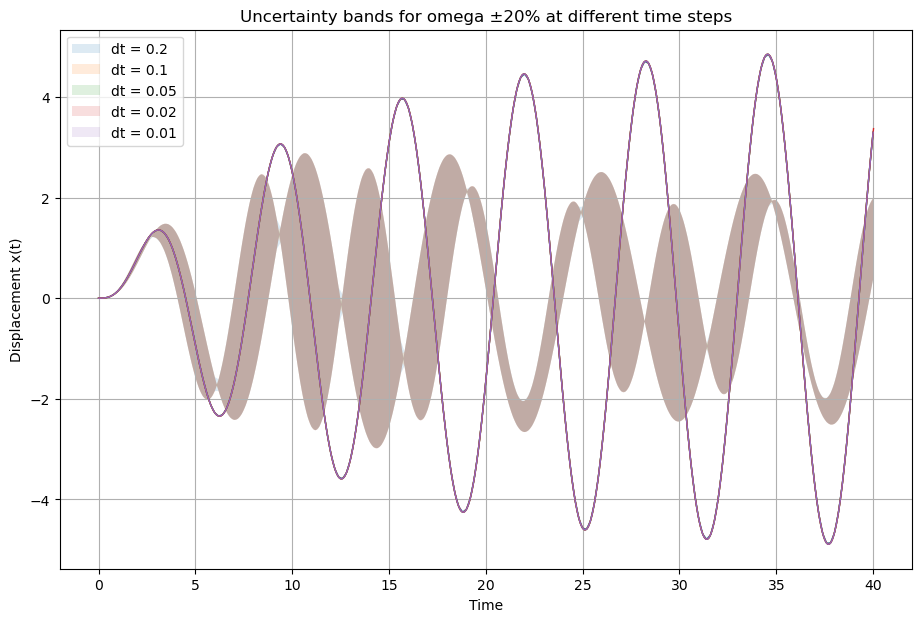

In [10]:
plt.figure(figsize=(11, 7))

for dt in dt_values:
  runs = all_results[dt]

  _, t_low, u_low, _ = runs[0]
  _, t_mid, u_mid, _ = runs[1]
  _, t_high, u_high, _ = runs[2]

  u_min = np.minimum(u_low, u_high)
  u_max = np.maximum(u_low, u_high)

  plt.fill_between(t_mid, u_min, u_max, alpha=0.15, label=f"dt = {dt}")
  plt.plot(t_mid, u_mid, linewidth=1)

plt.xlabel("Time")
plt.ylabel("Displacement x(t)")
plt.title(f"Uncertainty bands for {param_name} ±20% at different time steps")
plt.grid(True)
plt.legend()
plt.show()

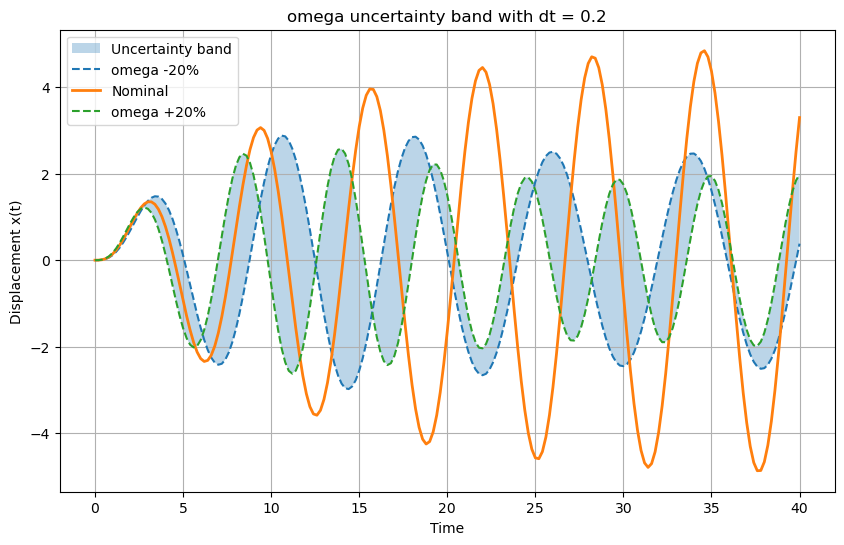

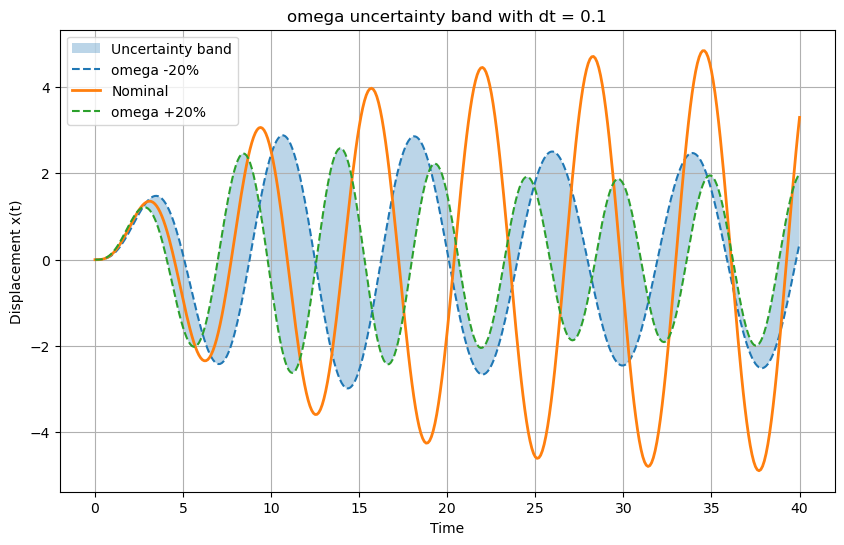

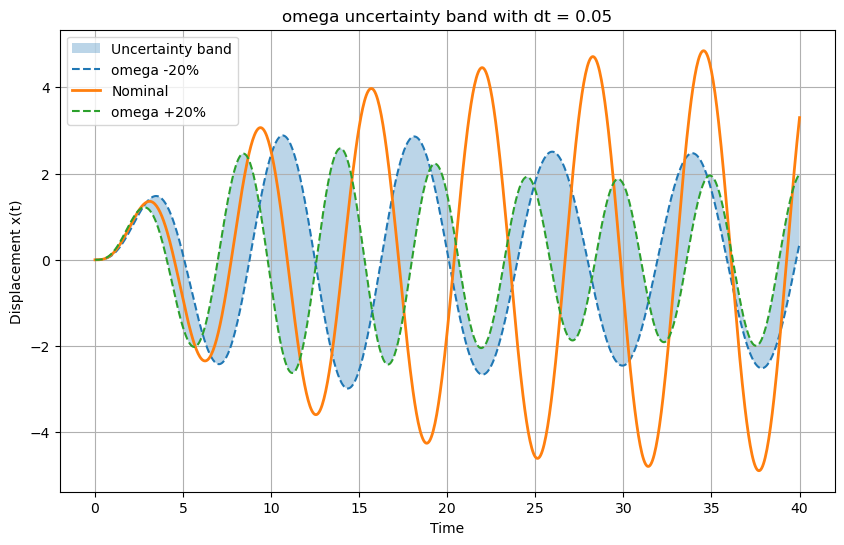

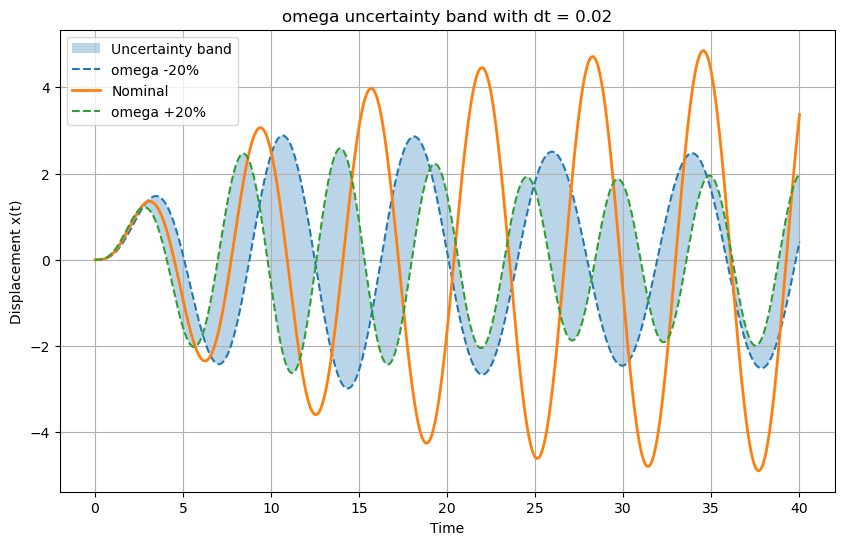

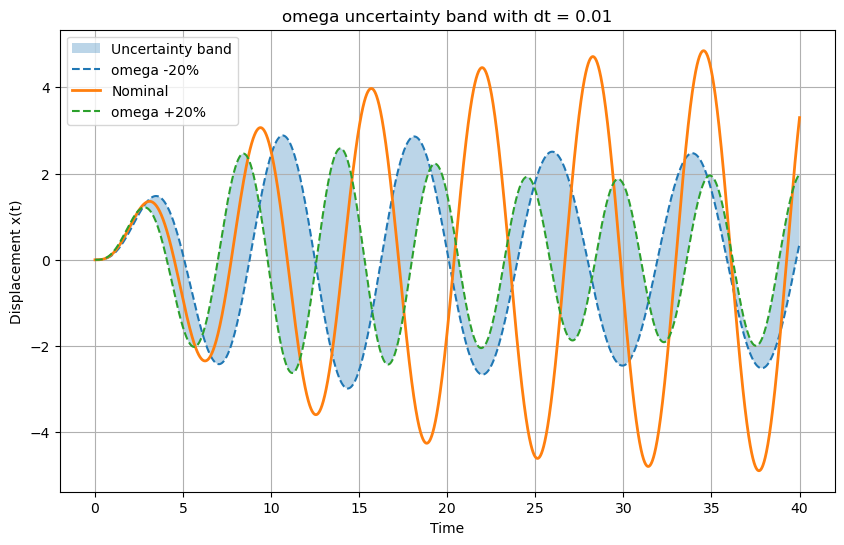

In [11]:
for dt in dt_values:
  runs = all_results[dt]

  val_low, t_low, u_low, _ = runs[0]
  val_mid, t_mid, u_mid, _ = runs[1]
  val_high, t_high, u_high, _ = runs[2]

  u_min = np.minimum(u_low, u_high)
  u_max = np.maximum(u_low, u_high)

  plt.figure(figsize=(10, 6))
  plt.fill_between(t_mid, u_min, u_max, alpha=0.3, label="Uncertainty band")
  plt.plot(t_low, u_low, linestyle='--', label=f"{param_name} -20%")
  plt.plot(t_mid, u_mid, linewidth=2, label="Nominal")
  plt.plot(t_high, u_high, linestyle='--', label=f"{param_name} +20%")

  plt.xlabel("Time")
  plt.ylabel("Displacement x(t)")
  plt.title(f"{param_name} uncertainty band with dt = {dt}")
  plt.grid(True)
  plt.legend()
  plt.show()

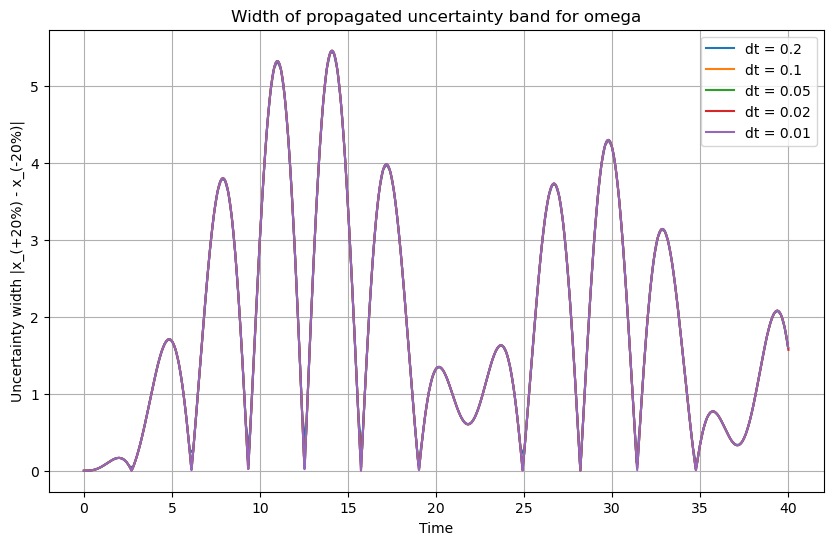

Maximum uncertainty band widths:
dt =  0.2: max band width = 5.429461
dt =  0.1: max band width = 5.452827
dt = 0.05: max band width = 5.452827
dt = 0.02: max band width = 5.452827
dt = 0.01: max band width = 5.452943


In [12]:
plt.figure(figsize=(10, 6))

max_widths = []

for dt in dt_values:
  runs = all_results[dt]

  _, t_low, u_low, _ = runs[0]
  _, t_mid, u_mid, _ = runs[1]
  _, t_high, u_high, _ = runs[2]

  width = np.abs(u_high - u_low)
  max_width = np.max(width)
  max_widths.append(max_width)

  plt.plot(t_mid, width, label=f"dt = {dt}")

plt.xlabel("Time")
plt.ylabel("Uncertainty width |x_(+20%) - x_(-20%)|")
plt.title(f"Width of propagated uncertainty band for {param_name}")
plt.grid(True)
plt.legend()
plt.show()

print("Maximum uncertainty band widths:")
for dt, mw in zip(dt_values, max_widths):
  print(f"dt = {dt:>4}: max band width = {mw:.6f}")

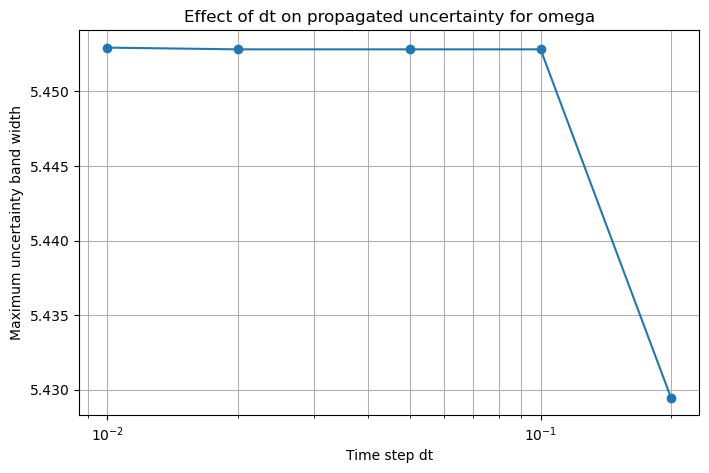

In [13]:
plt.figure(figsize=(8, 5))
plt.semilogx(dt_values, max_widths, marker='o')
plt.xlabel("Time step dt")
plt.ylabel("Maximum uncertainty band width")
plt.title(f"Effect of dt on propagated uncertainty for {param_name}")
plt.grid(True, which="both")
plt.show()

**f.**
Basically, the uncertainty is going to be there no matter what your time step is. If your data is inaccurate, precision can't fix it.

**g.**
The periodic nature of the underlying function and the external force has a unique interaction, where the confidence bounds get very messy when it's mismatched. If uncertainty changes as a function of delta_t, it's fixable by smaller intervals, meaning it's a precision error, not an accuracy. It's an error with the numerical method. If your mesh is too big, you might not see the strongest stresses in ansys. However, if your condition is inaccurate, no amount of mesh refinement fixes your model.
<br><br>
The findings have to be explained with uncertainty. The reliability also needs to be communicated to be through the time step. But in general if you have a good safety factor, life should be all good. As long as it fits the code. If it does, you're beyond the liability of a competent individual, meaning you can move on with life.